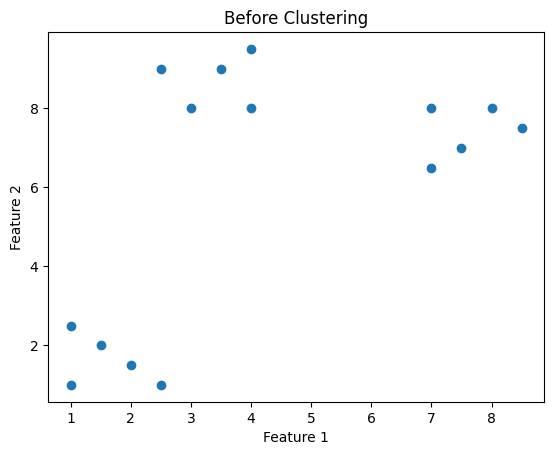

In [3]:
# Sklearn implementation using data from manual implemenation
# We will train on several number of clusters then choose cluster by elbow method
# First run is just to check the code

from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1.0, 1.0],
    [1.5, 2.0],
    [2.0, 1.5],
    [1.0, 2.5],
    [2.5, 1.0],

    [7.0, 8.0],
    [8.0, 8.0],
    [7.5, 7.0],
    [8.5, 7.5],
    [7.0, 6.5],

    [3.0, 8.0],
    [3.5, 9.0],
    [4.0, 8.0],
    [2.5, 9.0],
    [4.0, 9.5]
])

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Before Clustering")
plt.show()

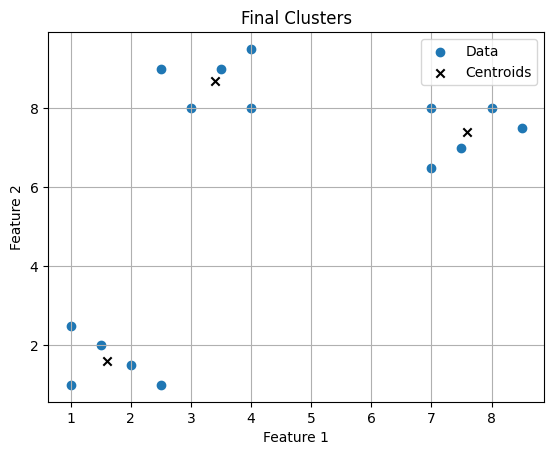

In [9]:
# Model training
# Remember default values (except n_iter) are the best options in many cases
# That is why I am using default values
kmean = KMeans(3)
kmean.fit(X)

# Get position of final clusters
clusters = kmean.cluster_centers_

# Plot
plt.scatter(X[:, 0], X[:, 1], label = "Data")
plt.scatter(clusters[:, 0], clusters[:, 1], color = "black", marker = "x", label = "Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Final Clusters")
plt.legend()
plt.grid()
plt.show()

In [13]:
# Elbow method
inertia_hist = []
num_cluster = [i for i in range(1, 15)]

for i in num_cluster:
  kmean_i = KMeans(i)
  kmean_i.fit(X)

  inertia = kmean_i.inertia_
  inertia_hist.append(inertia)

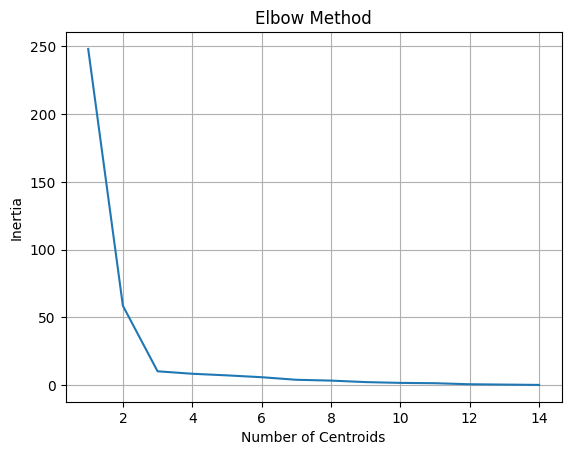

In [17]:
plt.plot(num_cluster, inertia_hist)
plt.xlabel("Number of Centroids")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

In [18]:
# So according to Elbow best number of centroids is 3
print("Best is 3")

Best is 3


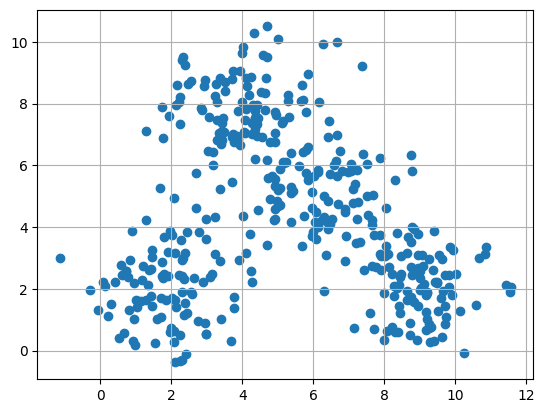

In [19]:
# Check another dataset
np.random.seed(42)

cluster1 = np.random.normal([2, 2], 1.2, (100, 2))
cluster2 = np.random.normal([6, 5], 1.3, (100, 2))
cluster3 = np.random.normal([4, 8], 1.1, (100, 2))
cluster4 = np.random.normal([9, 2], 1.0, (100, 2))

X = np.vstack((cluster1, cluster2, cluster3, cluster4))

plt.scatter(X[:,0], X[:,1])
plt.grid(True)
plt.show()

In [31]:
# Elbow method for new data
inertia_hist = []
num_cluster = [i for i in range(1, 30)]

for i in num_cluster:
  kmean = KMeans(i)
  kmean.fit(X)

  inertia = kmean.inertia_
  inertia_hist.append(inertia)

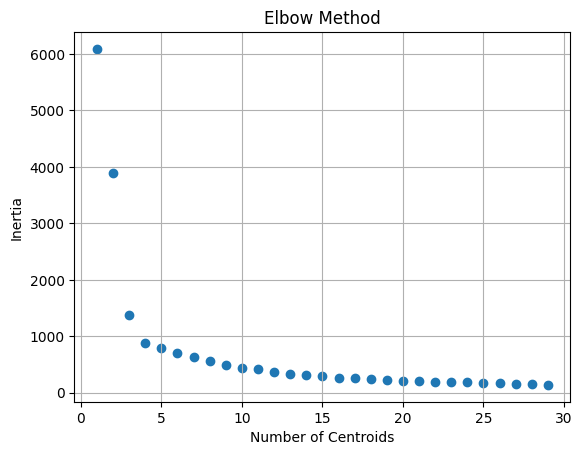

In [33]:
# Plot elbow
plt.scatter(num_cluster, inertia_hist)
plt.xlabel("Number of Centroids")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

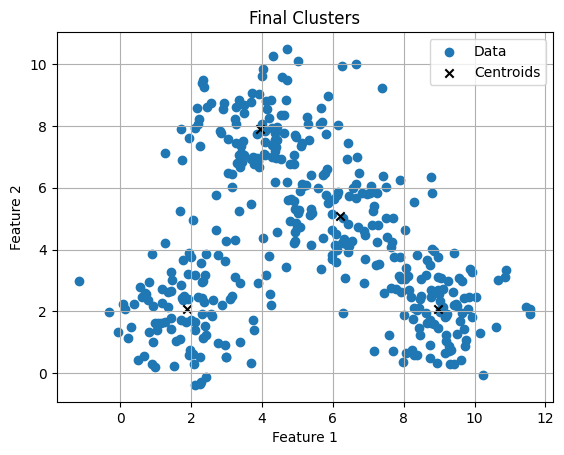

In [34]:
# So according to the elbow as we can see best is 4
kmean = KMeans(4)
kmean.fit(X)

# Get position of final clusters
clusters = kmean.cluster_centers_

# Plot
plt.scatter(X[:, 0], X[:, 1], label = "Data")
plt.scatter(clusters[:, 0], clusters[:, 1], color = "black", marker = "x", label = "Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Final Clusters")
plt.legend()
plt.grid()
plt.show()

In [37]:
# Best number of cluster through Silhouette Analysis
from sklearn.metrics import silhouette_score

scores = []
num_cluster = [i for i in range(2, 30)]

for k in num_cluster:
    kmeans = KMeans(n_clusters=k)

    labels = kmeans.fit(X).labels_

    score = silhouette_score(X, labels)
    scores.append(score)

    print(f"k = {k}   Silhouette Score = {score:.3f}")


k = 2   Silhouette Score = 0.427
k = 3   Silhouette Score = 0.559
k = 4   Silhouette Score = 0.531
k = 5   Silhouette Score = 0.460
k = 6   Silhouette Score = 0.375
k = 7   Silhouette Score = 0.374
k = 8   Silhouette Score = 0.323
k = 9   Silhouette Score = 0.374
k = 10   Silhouette Score = 0.322
k = 11   Silhouette Score = 0.320
k = 12   Silhouette Score = 0.342
k = 13   Silhouette Score = 0.356
k = 14   Silhouette Score = 0.341
k = 15   Silhouette Score = 0.350
k = 16   Silhouette Score = 0.348
k = 17   Silhouette Score = 0.361
k = 18   Silhouette Score = 0.333
k = 19   Silhouette Score = 0.343
k = 20   Silhouette Score = 0.337
k = 21   Silhouette Score = 0.334
k = 22   Silhouette Score = 0.341
k = 23   Silhouette Score = 0.350
k = 24   Silhouette Score = 0.343
k = 25   Silhouette Score = 0.358
k = 26   Silhouette Score = 0.341
k = 27   Silhouette Score = 0.368
k = 28   Silhouette Score = 0.351
k = 29   Silhouette Score = 0.331


In [40]:
# According to Silhouette Score
best_num_clust = num_cluster[scores.index(max(scores))]
print(f"Best number of cluster: {best_num_clust}")

Best number of cluster: 3


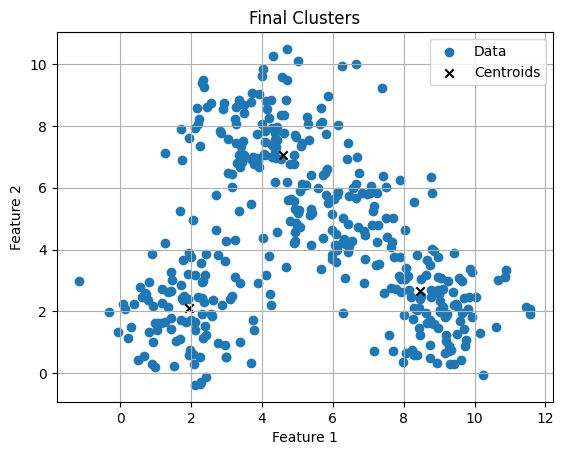

In [41]:
# So according to the elbow as we can see best is 4
kmean = KMeans(n_clusters=best_num_clust)
kmean.fit(X)

# Get position of final clusters
clusters = kmean.cluster_centers_

# Plot
plt.scatter(X[:, 0], X[:, 1], label = "Data")
plt.scatter(clusters[:, 0], clusters[:, 1], color = "black", marker = "x", label = "Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Final Clusters")
plt.legend()
plt.grid()
plt.show()